# Monte Carlo VaR with Financial Modeling Prep

This notebook pulls historical prices from Financial Modeling Prep (FMP), builds a sample
portfolio, and estimates Value-at-Risk (VaR) using a Monte Carlo simulation.


## Prerequisites
- Set your FMP API key as an environment variable: `FMP_API_KEY`
- Install dependencies: `pip install pandas numpy requests matplotlib`

You can get an API key at https://financialmodelingprep.com/developer/docs


In [ ]:
import time
import os
os.environ["FMP_API_KEY"] = "XXXX"

In [26]:
import os
import math
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
pd.set_option("display.width", 120)

FMP_API_KEY = os.getenv("FMP_API_KEY", "").strip()
if not FMP_API_KEY:
    raise RuntimeError("Set FMP_API_KEY in your environment before running this notebook.")


## Download historical prices
We will download adjusted close prices for a small sample portfolio.


In [27]:
TICKERS = ["AAPL", "MSFT", "NVDA", "JPM"]
END_DATE = datetime.utcnow().date()
START_DATE = END_DATE - timedelta(days=365 * 2)

def fetch_prices_fmp(ticker, start_date, end_date, api_key):
    url = f"https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}"
    params = {
        "from": start_date.strftime("%Y-%m-%d"),
        "to": end_date.strftime("%Y-%m-%d"),
        "serietype": "line",
        "apikey": api_key,
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    if "historical" not in data:
        raise ValueError(f"No historical data for {ticker}: {data}")
    df = pd.DataFrame(data["historical"])
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")["close"].sort_index()
    df.name = ticker
    return df

price_series = [fetch_prices_fmp(t, START_DATE, END_DATE, FMP_API_KEY) for t in TICKERS]
prices = pd.concat(price_series, axis=1).dropna()
prices.tail()


/tmp/ipykernel_16909/629114143.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  END_DATE = datetime.utcnow().date()


,AAPL,MSFT,NVDA,JPM
date,,,,
2026-01-05,267.26000,472.850,188.120,334.04
2026-01-06,262.36000,478.510,187.240,334.67
2026-01-07,260.33000,483.470,189.110,326.99
2026-01-08,259.04000,478.110,185.040,329.79
2026-01-09,257.76999,474.535,184.555,331.10


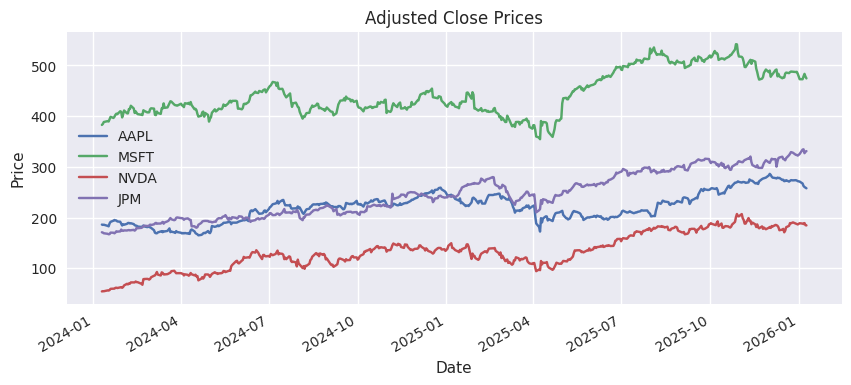

In [28]:
prices.plot(figsize=(10, 4), title="Adjusted Close Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


## Build a sample portfolio
Define portfolio weights (must sum to 1.0). We'll use a simple equal-weight portfolio.


In [29]:
weights = np.array([1.0 / len(TICKERS)] * len(TICKERS))
weights


array([0.25, 0.25, 0.25, 0.25])

## Compute returns
We will use daily log returns for the simulation.


In [30]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.head()


,AAPL,MSFT,NVDA,JPM
date,,,,
2024-01-11,-0.003228,0.004848,0.008610,-0.004219
2024-01-12,0.001777,0.009934,-0.002009,-0.007367
2024-01-16,-0.012394,0.004623,0.030068,-0.006290
2024-01-17,-0.005187,-0.002052,-0.005870,-0.005372
2024-01-18,0.032051,0.011234,0.018735,0.001973


## Monte Carlo VaR
We simulate correlated returns using the historical mean and covariance.
Change `NUM_SIMULATIONS`, `HORIZON_DAYS`, and `CONFIDENCE` as needed.


In [31]:
NUM_SIMULATIONS = 2_000_000
HORIZON_DAYS = 10
CONFIDENCE = 0.95
USE_GPU = True  # requires cupy in the environment
# Ensure cupy is defined for this cell
try:
    import cupy as cp
except Exception:
    cp = None


mu = log_returns.mean().values
cov = log_returns.cov().values

def simulate_var(num_simulations, horizon_days, weights, mu, cov, use_gpu=True):
    if use_gpu and cp is not None:
        xp = cp
        backend = "cuda"
    else:
        xp = np
        backend = "cpu"

    mu_h = mu * horizon_days
    cov_h = cov * horizon_days

    t0 = time.perf_counter()
    z = xp.random.standard_normal((num_simulations, len(mu))).astype(xp.float32)
    chol = xp.linalg.cholesky(xp.asarray(cov_h, dtype=xp.float32))
    sim = z @ chol.T + xp.asarray(mu_h, dtype=xp.float32)
    port_log_returns = sim @ xp.asarray(weights, dtype=xp.float32)
    port_simple_returns = xp.exp(port_log_returns) - 1.0
    elapsed = time.perf_counter() - t0

    if xp is cp:
        port_simple_returns = cp.asnumpy(port_simple_returns)

    return port_simple_returns, elapsed, backend

port_simple_returns, elapsed, backend = simulate_var(
    NUM_SIMULATIONS, HORIZON_DAYS, weights, mu, cov, USE_GPU
)

var_level = 1.0 - CONFIDENCE
var_value = np.quantile(port_simple_returns, var_level)

print(f"{int(CONFIDENCE*100)}% {HORIZON_DAYS}-day VaR: {abs(var_value):.2%}")
print(f"Simulations: {NUM_SIMULATIONS:,} | Backend: {backend} | Elapsed: {elapsed:.3f}s")


95% 10-day VaR: 6.19%
Simulations: 2,000,000 | Backend: cpu | Elapsed: 0.196s


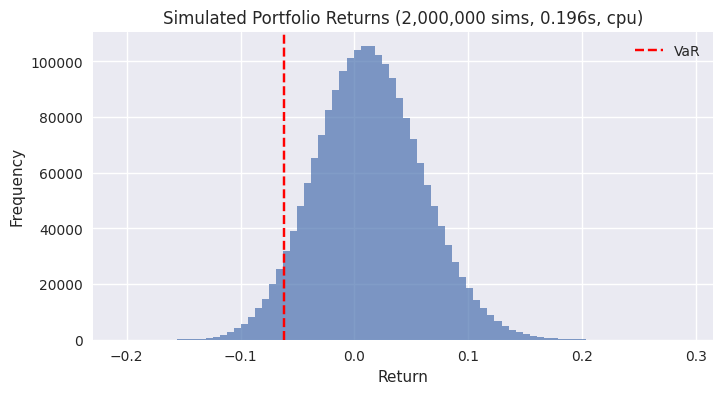

In [32]:
plt.figure(figsize=(8, 4))
plt.hist(port_simple_returns, bins=80, alpha=0.7)
plt.axvline(var_value, color="red", linestyle="--", label="VaR")
plt.title(f"Simulated Portfolio Returns ({NUM_SIMULATIONS:,} sims, {elapsed:.3f}s, {backend})")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()


## Optional: Export results
Save your simulated return distribution for downstream analysis.


In [33]:
output_path = "/home/ubuntu/monte-carlo-GPU-CUDA/results/var_simulated_returns.csv"
pd.Series(port_simple_returns, name="simulated_return").to_csv(output_path, index=False)
print(f"Saved simulated returns to {output_path}")


Saved simulated returns to /home/ubuntu/monte-carlo-GPU-CUDA/results/var_simulated_returns.csv
